In [1]:
import sys
sys.path.append('..')

import random
import pickle as pkl
import matplotlib.pyplot as plt 
from collections import defaultdict
from tensorflow.keras.models import load_model

from lib_dolphin.audio import * 
from lib_dolphin.parameters import *
from lib_dolphin.features import * 

2024-04-27 11:17:39.133387: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-27 11:17:39.371600: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-27 11:17:40.726738: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/lib64
2024-04-27 11:17:40.726867: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; 

# Generate L1- Dataset

In [16]:
LABEL_FILE = '../../datasets/l1.csv'
WAV_FILE = '../../datasets/l1.wav'

instances, ra, labels, label_dict = dataset_supervised_windows(
    LABEL_FILE, WAV_FILE, lo=FFT_LO, hi=FFT_HI, win=FFT_WIN, step=FFT_STEP, raw_size=RAW_AUDIO)    


DIFF: 0


In [17]:
reverse_label_dict = {v:k for k, v in label_dict.items()} 
label_resolved = [reverse_label_dict[l] for l in labels]

In [18]:
grouped = defaultdict(list)
for l, i in zip(label_resolved, instances):
    grouped[l].append(i)


In [19]:
N = 25
sampled = {}
for k, items in grouped.items():
    sampled[k] = np.stack(random.sample(items, N))

In [37]:
pkl.dump(sampled, open("this_img.pkl", 'wb'))

In [40]:
sampled = pkl.load(open("this_img.pkl", "rb"))

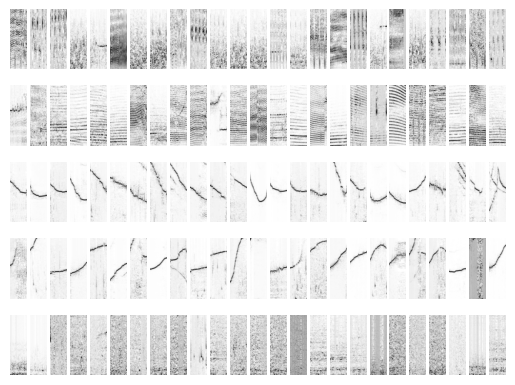

In [41]:
fig, ax = plt.subplots(5, N)
for l, items in sampled.items():
    for i in range(0, N):
        ax[label_dict[l], i].imshow(1.0 - items[i, :, :].T, cmap='gray')
        ax[label_dict[l], i].axis('off')
        
                
plt.savefig('l1_dataset.png', bbox_inches='tight')

In [57]:
reverse_label_dict

{0: 'ECHO', 1: 'BURST', 2: 'WSTL_DOWN', 3: 'WSTL_UP', 4: 'NOISE'}

# A single Example

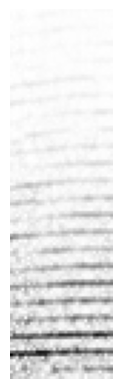

In [29]:
plt.imshow(1-sampled['BURST'][5].T, cmap='gray')
plt.axis('off')
plt.savefig('burst.png', bbox_inches='tight')

# AE Plot Reconstructions

In [57]:
ae = load_model('../static/web_service/ml_models_v3/ae.h5')

In [64]:
reconstructions = {}
for k, samples in sampled.items():
    reconstructions[k] = ae.predict(samples)

1/1 [==============================] - 0s 38ms/step


(25, 36, 130, 1)
(25, 36, 130, 1)
(25, 36, 130, 1)
(25, 36, 130, 1)
(25, 36, 130, 1)


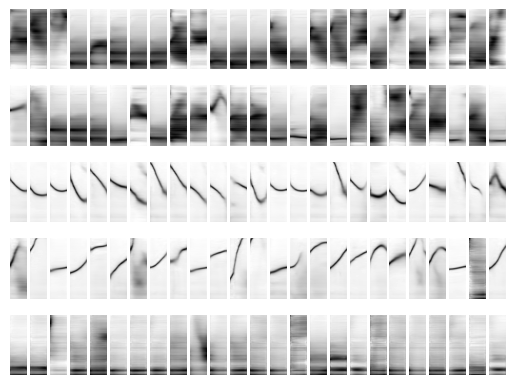

In [72]:
fig, ax = plt.subplots(5, N)
for l, items in reconstructions.items():
    print(items.shape)
    items = items.reshape((25, 36, 130))
    for i in range(0, N):
        ax[label_dict[l], i].imshow(1.0 - items[i, :, :].T, cmap='gray')
        ax[label_dict[l], i].axis('off')                
plt.savefig('reconstructions.png', bbox_inches='tight')

# Encoder Filters

In [82]:
filters = {}
for s in range(0, 2 * N_BANKS, 2):
    w = ae.weights[s].numpy()
    d = w.shape
    w = w.reshape((d[0], d[1], d[3]))
    k = "_".join([str(x) for x in w.shape])
    filters[k] = w

(8, 8, 32)
(4, 16, 32)
(2, 32, 32)
(1, 64, 32)
(8, 4, 32)
(16, 4, 32)
(32, 4, 32)


<Figure size 640x480 with 0 Axes>

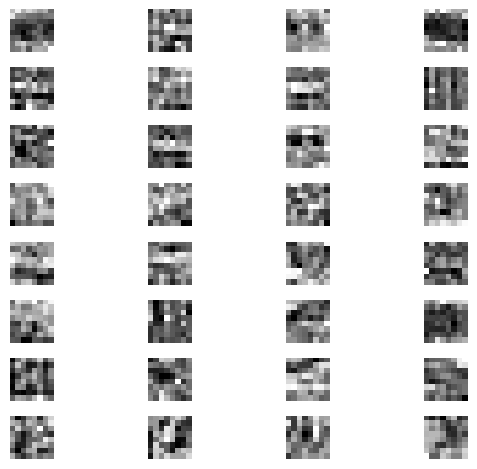

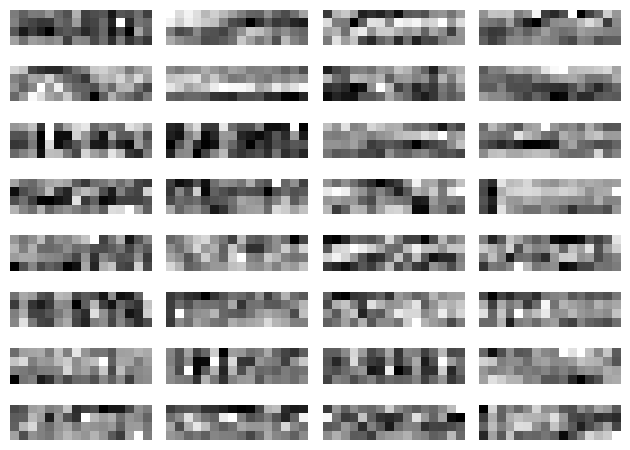

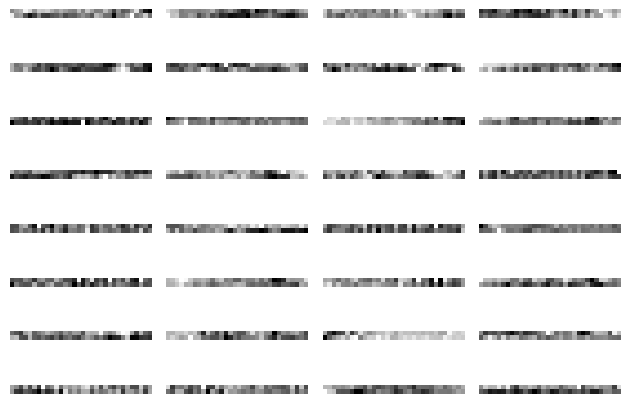

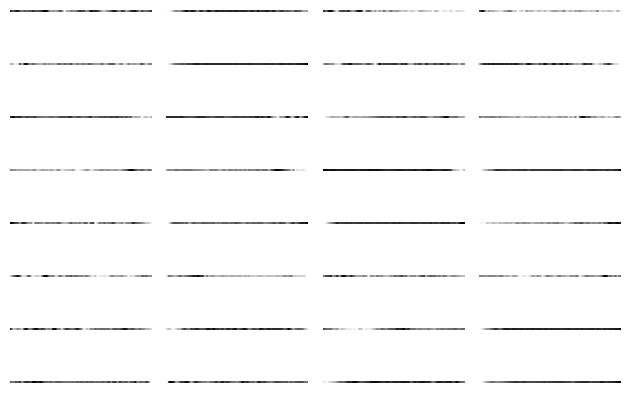

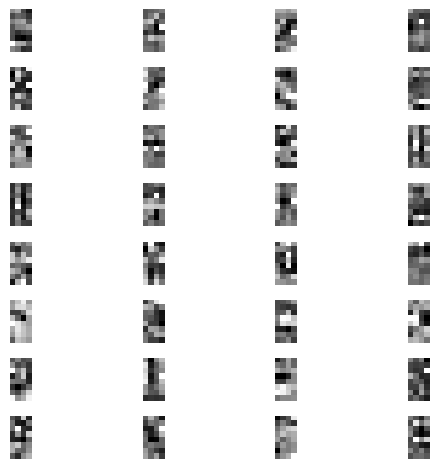

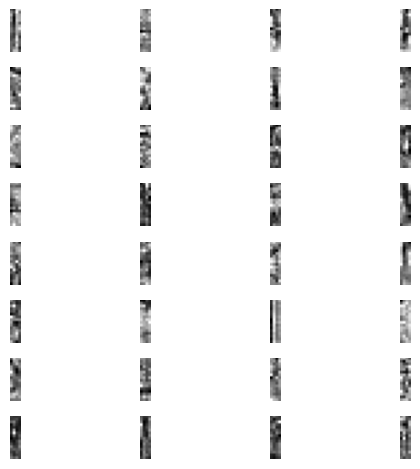

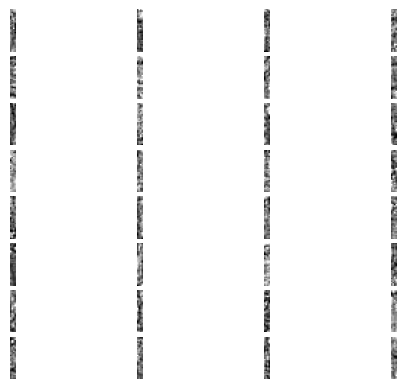

In [95]:
for k, f in filters.items():
    plt.tight_layout()
    fig, ax = plt.subplots(8, 4)
    print(f.shape)
    a = 0
    for i in range(0, 8):
        for j in range(0, 4):
            ax[i, j].imshow(1.0 - f[:, :, a], cmap='gray')
            ax[i, j].axis('off')                
            
            a += 1
    fig.subplots_adjust(wspace=.1, hspace=.1)
    plt.savefig(f'{k}.png', bbox_inches='tight')

# Example Spectrogram

In [47]:
x = raw('../../datasets/example.wav')    
s = spectrogram(x)
print(s.shape)


(989, 180)


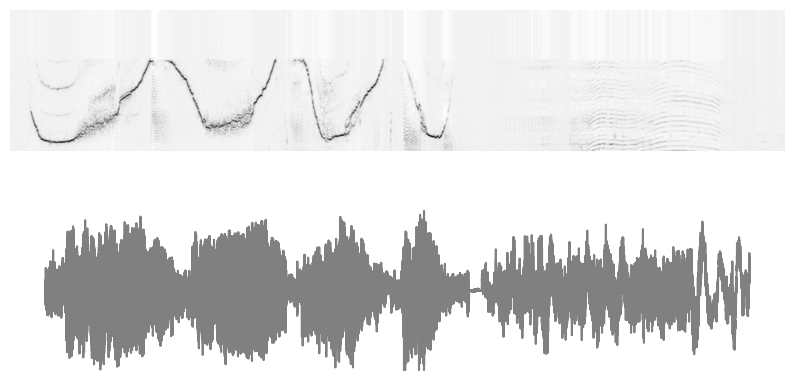

In [54]:
plt.figure(figsize=(10,5))
plt.subplot(2, 1, 1)
plt.imshow(1.0 - s.T, cmap='gray')
plt.axis('off')
plt.subplot(2, 1, 2)
plt.plot(x, color='gray')
plt.axis('off')
plt.savefig('example.png', bbox_inches='tight')
plt.show()

# Example convolutions

In [57]:
ae = load_model('../static/web_service/ml_models_v3/ae.h5')
filters = {}
for s in range(0, 2 * N_BANKS, 2):
    w = ae.weights[s].numpy()
    d = w.shape
    w = w.reshape((d[0], d[1], d[3]))
    k = "_".join([str(x) for x in w.shape])
    filters[k] = w

2024-04-27 11:44:26.633763: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-27 11:44:28.227792: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3608 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [68]:
filters.keys()

dict_keys(['8_8_32', '4_16_32', '2_32_32', '1_64_32', '8_4_32', '16_4_32', '32_4_32'])

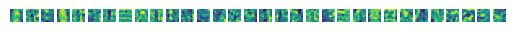

In [71]:
for i in range(0, 32):
    plt.subplot(1, 32, i + 1)
    plt.imshow(filters['8_8_32'][:, :, i].T) 
    plt.axis('off')

In [ ]:
np.convolve()

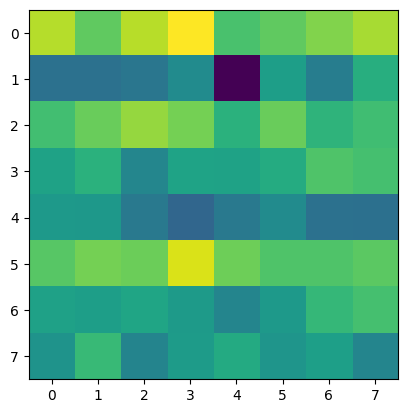

In [73]:
plt.imshow(filters['8_8_32'][:, :, 7].T) 